<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-14/RandomForestCensus0604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Carregamento de Dados | Random Forest Base [Fase 1 - census_data]

## Importar dados do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

# Pipeline Random Forest | Random Forest Base [Fase 2 - census_data]

## Treinamento da Floresta Aleatoria

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
random_forest_census_data = RandomForestClassifier(

    n_estimators=10,

    criterion='entropy',

    max_depth=10,

    min_samples_leaf=5,

    random_state=0
)

random_forest_census_data.fit(
    X_census_treinamento,
    Y_census_treinamento
)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       n_estimators=10, random_state=0)

In [10]:
modelo = RandomForestClassifier(

    n_estimators=200,          # quantidade de arvores na floresta

    criterion='entropy',       # medida usada para escolher as divisoes

    max_depth=10,              # profundidade maxima de cada arvore

    min_samples_leaf=5,        # numero minimo de amostras em cada folha

    min_samples_split=2,       # numero minimo de amostras para dividir um no

    max_features=None,         # quantidade de atributos analisados em cada divisao

    max_leaf_nodes=None,       # numero maximo de folhas por arvore

    class_weight=None,         # peso das classes

    ccp_alpha=0.0,             # poda por complexidade de custo

    random_state=0,            # garante reproducibilidade dos resultados

    n_jobs=-1                  # utiliza todos os nucleos do processador
)

# Pipeline Medicoes Harmonicas | Random Forest Base [Fase 3 - census_data]

## Avaliacao da Floresta Aleatoria

In [11]:
previsoes_floresta = random_forest_census_data.predict(X_census_teste)

In [12]:
previsoes_floresta

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [13]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
accuracy_score(Y_census_teste, previsoes_floresta)

0.8472876151484136

In [16]:
from yellowbrick.classifier import ConfusionMatrix

In [17]:
print(classification_report(Y_census_teste, previsoes_floresta))

              precision    recall  f1-score   support

       <=50K       0.86      0.96      0.90      3693
        >50K       0.80      0.50      0.62      1192

    accuracy                           0.85      4885
   macro avg       0.83      0.73      0.76      4885
weighted avg       0.84      0.85      0.83      4885



0.8472876151484136

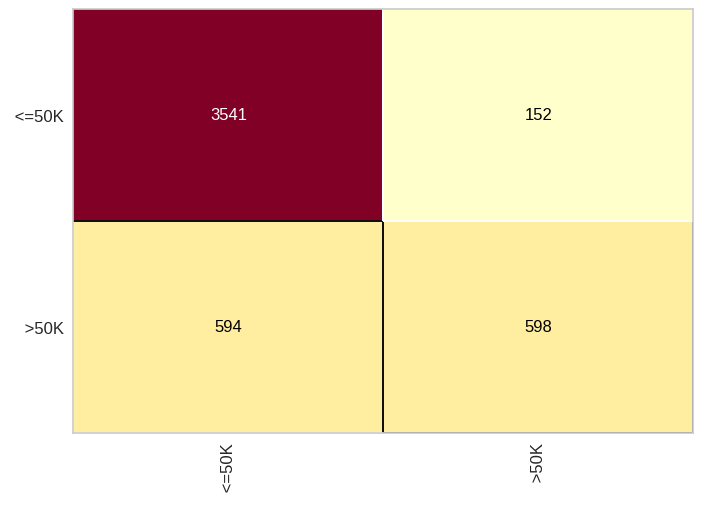

In [18]:
cm_census_rf = ConfusionMatrix(random_forest_census_data)
cm_census_rf.fit(X_census_treinamento, Y_census_treinamento)
cm_census_rf.score(X_census_teste, Y_census_teste)